In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import pywt, math
from dst.filters import get_filters
import matplotlib.pyplot as plt
import numpy as np

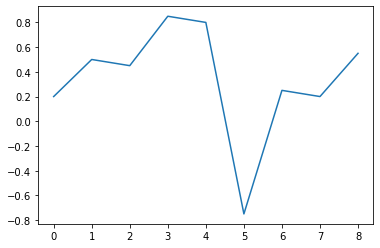

In [3]:
pattern = [0.20, 0.50, 0.45, 0.85, 0.80, -0.75, 0.25, 0.20, 0.55]
plt.plot(np.arange(0,len(pattern),1),pattern)
plt.show()

In [7]:
dec_lo, dec_hi, rec_lo, rec_hi = get_filters(pattern)
filter_bank = [[i for i in dec_lo.values()], [i for i in dec_hi.values()], [i for i in rec_lo.values()], [i for i in rec_hi.values()]]
myWavelet = pywt.Wavelet(name="myWavelet", filter_bank=filter_bank)

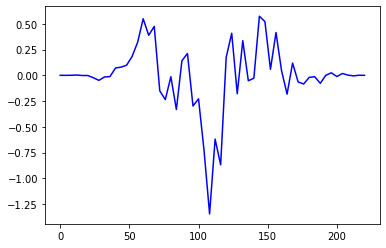

In [5]:
phi_d, psi_d, phi_r, psi_r, x = myWavelet.wavefun(5)

step = 4
psi_x = [i for i in range(0, len(psi_d), step )]
psi_d_ = [psi_d[i] for i in range(0, len(psi_d), step)]
plt.plot(psi_x, psi_d_, 'b-')
plt.show()

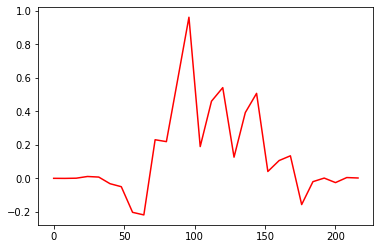

In [6]:
step = 8
phi_x = [i for i in range(0, len(phi_d), step)]
phi_d_ = [phi_d[i] for i in range(0, len(phi_d), step)]
plt.plot(phi_x, phi_d_, 'r-')
plt.show()

In [ ]:
def signal(x):
    if x >= 0 and x <= 40:
        return math.cos((math.pi *27*x)/8)*math.sin((math.pi *75*x)/8)
    elif x >= 41 and x <= 49:
        return m[int(x)-41]
    else: # 50 <= x <= 63
        return math.cos((math.pi *295*x)/32)*math.sin((math.pi *105*x)/32)
x = np.arange(

ValueError: x and y must have same first dimension, but have shapes (70,) and (82,)

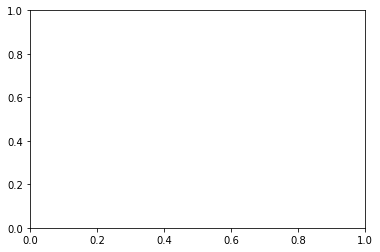

In [49]:
(cA, cD) = pywt.dwt(y, myWavelet)
y = np.concatenate([cA,cD])

alpha = 0.1
s = [math.exp(-(np.abs(y_[i])**alpha)) for i in range(len(y_))]
x = [i for i in range(70)]
plt.plot(x, y)
plt.plot(x, s, 'b-')
plt.show()